In [1]:
import os
import numpy as np
import psutil
import spatioloji_s as sj

In [2]:
mem = psutil.virtual_memory()
print(f"Total memory available: {mem.total / 1024**3:.2f} GB")
cpus = os.cpu_count()
print(f"Total cpu cores available: {cpus}")
print(f"current work directory is {os.getcwd()}")

Total memory available: 251.40 GB
Total cpu cores available: 64
current work directory is /carc/scratch/projects/amitra2016502/spatioloji_s/example


In [3]:
# Load your spatioloji object
sp = sj.data.spatioloji.from_pickle('my_qc_output/data/filtered_spatioloji.pkl')


Loading spatioloji from: my_qc_output/data/filtered_spatioloji.pkl
✓ Loaded: 25,368 cells × 960 genes


In [4]:
# Normalize data
sj.processing.normalize_total(sp, target_sum=1e4, inplace=True)
sj.processing.log_transform(sp, layer='normalized_counts', inplace=True)

# Select highly variable genes
# # of HVG may be less than n_top_genes because we have other cut-off values to filter
sj.processing.highly_variable_genes(sp, n_top_genes=200, inplace=True, min_disp=0, min_mean=0)

# scale data
sj.processing.scale_by_batch_normalization(sp, layer='log_normalized', method='standard', max_value=10.0, 
                                           batch_key='fov', output_layer="fov_scaled",inplace=True)

# Dimensionality reduction
sj.processing.pca(sp, n_comps=50, inplace=True, layer='fov_scaled')
sj.processing.umap(sp, use_pca=True, inplace=True, n_neighbors=30, n_pcs=20, min_dist=0.3)


Normalizing expression to target sum: 10,000
  Counts per cell - mean: 179, median: 140
  ✓ Normalized 25,368 cells × 960 genes
✓ Added layer 'normalized_counts' (dense, 185.8 MB)

Applying log transformation (base=e)
  ✓ Transformed 25,368 cells × 960 genes
✓ Added layer 'log_normalized' (dense, 185.8 MB)

Identifying highly variable genes (method=seurat)
  Using Seurat method (n_top_genes=200)
  ✓ Selected 200 highly variable genes
    Mean expression range: 0.02 - 2.63

Batch-wise scaling (batch_key='fov', method=standard)
  Found 20 batches
  Clipped values to [-10.0, 10.0]
  ✓ Scaled 25,368 cells × 960 genes across batches
✓ Added layer 'fov_scaled' (dense, 185.8 MB)

Computing PCA (n_comps=50)
  Using 200 highly variable genes
  Running PCA...
  ✓ PCA complete
    Variance explained by first 10 PCs: 17.8%
    Variance explained by all 50 PCs: 39.1%


/users/jiwang1/.conda/envs/spatioloji/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-04 21:28:26.090842: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-04 21:28:26.143093: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-04 21:28:28.152483: I tensorflow/c


UMAP (n_components=2, n_neighbors=30, min_dist=0.3)
  Using first 20 PCs as input
  Running UMAP...


/users/jiwang1/.conda/envs/spatioloji/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  ✓ UMAP complete


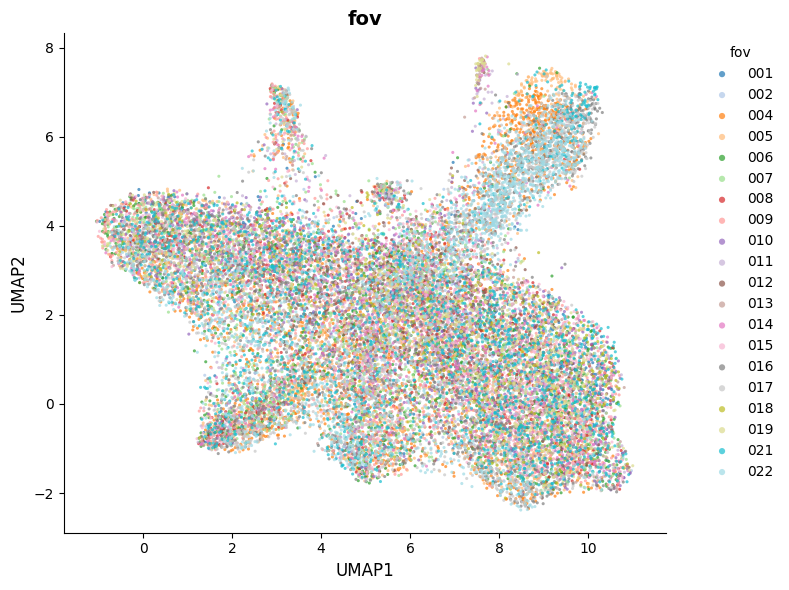

In [5]:
sj.visualization.plot_umap(sp,
                           color_by='fov',
                           show=True)

In [6]:
sp.cell_meta.columns

Index(['fov', 'cell_ID', 'Area', 'AspectRatio', 'CenterX_local_px',
       'CenterY_local_px', 'CenterX_global_px', 'CenterY_global_px', 'Width',
       'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK',
       'Max.PanCK', 'Mean.CD45', 'Max.CD45', 'Mean.CD3', 'Max.CD3',
       'Mean.DAPI', 'Max.DAPI', 'total_counts', 'n_genes_by_counts',
       'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_NegProbe',
       'QC_NegProbe_outlier', 'QC_Area_outlier', 'ratio_counts_genes',
       'QC_pass', 'qc_filtered', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6',
       'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15',
       'PC16', 'PC17', 'PC18', 'PC19', 'PC20', 'PC21', 'PC22', 'PC23', 'PC24',
       'PC25', 'PC26', 'PC27', 'PC28', 'PC29', 'PC30', 'PC31', 'PC32', 'PC33',
       'PC34', 'PC35', 'PC36', 'PC37', 'PC38', 'PC39', 'PC40', 'PC41', 'PC42',
       'PC43', 'PC44', 'PC45', 'PC46', 'PC47', 'PC48', 'PC49', 'PC50', 'UMAP1',
       'UMAP2'],
      dtype='object')

In [7]:
metrics_before = sj.processing.evaluate_batch_correction(
    sp,
    batch_key="fov",
    embedding_key="X_pca",   # uncorrected PCA
    n_neighbors=30
)


Evaluating batch correction...
  Batch mixing score: 0.887 (higher = better mixing)
  Silhouette (batch): -0.054 (lower = better)


In [8]:
sj.processing.regress_out(
    sp,
    keys=["pct_counts_mt"],            # regress out MT% only
    layer="log_normalized",        # input: log-normalized
    output_layer="regressed",      # output layer name
    inplace=True
)


Regressing out: ['pct_counts_mt']
  Regressing out effects...
  ✓ Regression complete
✓ Added layer 'regressed' (dense, 185.8 MB)


In [9]:
sj.processing.combat(
    sp,
    batch_key="fov",
    layer="log_normalized",         # input: log-normalized
    use_highly_variable=False,       # preserve condition differences
    output_layer="combat_corrected",
    inplace=True
)


ComBat batch correction (batch_key='fov')
  Found 20 batches
  Running ComBat...
Found 20 batches.
  Error running pycombat: 'NoneType' object is not subscriptable
  Trying alternative implementation...
  ✓ ComBat correction complete
✓ Added layer 'combat_corrected' (dense, 185.8 MB)


In [10]:
sj.processing.harmony(
    sp,
    batch_key="fov",
    n_pcs=30,                        # number of PCs to correct
    layer="scaled",                  # only used if PCA not found
    use_highly_variable=True,
    theta=2.0,                       # correction strength (higher = stronger)
    max_iter_harmony=20,
    output_key="X_pca_harmony",
    inplace=True
)


Harmony integration (batch_key='fov', theta=2.0)
  Found 20 batches
  Using existing PCA (30 PCs)
  Running Harmony (max_iter=20)...


2026-03-04 20:00:18,010 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-03-04 20:00:18,412 - harmonypy - INFO - KMeans initialization complete.


  ✓ Harmony integration complete
    Output shape: (25368, 30)


In [9]:
sj.processing.scvi_integrate(
    sp,
    batch_key="fov",
    layer="log_normalized",          # input: log-normalized (NOT raw counts here)
    n_latent=30,                     # latent space dimensions
    max_epochs=400,
    use_highly_variable=True,
    gene_likelihood="nb",            # negative binomial for UMI data
    conda_env="scvi_imputed",          # uncomment if scvi not in current env
    output_key="X_scvi",
    inplace=True
)


scVI integration (batch_key='fov', n_latent=30)
  Using 200 highly variable genes
  Running scVI in conda environment: 'scvi_imputed'
    Calling conda environment 'scvi_imputed'...

Epoch 100/400:  25%|▏| 99/400 [07:28<22:40,  4.52s/it, v_num=1, train_loss=120]
Epoch 100/400:  25%|▎| 100/400 [07:32<22:35,  4.52s/it, v_num=1, train_loss=120
Epoch 100/400:  25%|▎| 100/400 [07:32<22:35,  4.52s/it, v_num=1, train_loss=120
Epoch 101/400:  25%|▎| 100/400 [07:32<22:35,  4.52s/it, v_num=1, train_loss=120
Epoch 101/400:  25%|▎| 101/400 [07:37<22:30,  4.52s/it, v_num=1, train_loss=120
Epoch 101/400:  25%|▎| 101/400 [07:37<22:30,  4.52s/it, v_num=1, train_loss=120
Epoch 102/400:  25%|▎| 101/400 [07:37<22:30,  4.52s/it, v_num=1, train_loss=120
Epoch 102/400:  26%|▎| 102/400 [07:41<22:25,  4.52s/it, v_num=1, train_loss=120
Epoch 102/400:  26%|▎| 102/400 [07:41<22:25,  4.52s/it, v_num=1, train_loss=120
Epoch 103/400:  26%|▎| 102/400 [07:41<22:25,  4.52s/it, v_num=1, train_loss=120
Epoch 103/400:  

In [7]:
sj.processing.cca_integrate(
    sp,
    batch_key="fov",
    layer="log_normalized",          # input: log-normalized (NOT scaled)
    use_highly_variable=True,
    n_dims=30,
    n_features=200,
    conda_env="r_env",          # conda env with R + Seurat installed
    output_key="X_cca",
    inplace=True,
    n_cores=12
)


Seurat CCA integration (batch_key='fov')
  Found 20 batches
  Using 200 highly variable genes
    Executing R script (CCA)...
Using 12 core(s) for integration
Loading batch data...
Finding integration features...
Finding integration anchors (CCA)...
Integrating data...
Running PCA on integrated assay...
Saving output...
Done!


  ✓ CCA integration complete
    Output shape: (25368, 30)


In [8]:
sj.processing.rpca_integrate(
    sp,
    batch_key="fov",
    layer="log_normalized",          # input: log-normalized (NOT scaled)
    use_highly_variable=True,
    n_dims=30,
    n_features=200,
    conda_env="r_env",          # same conda env as CCA
    output_key="X_rpca",
    inplace=True,
    n_cores=12
)


Seurat RPCA integration (batch_key='fov')
  Found 20 batches
  Using 200 highly variable genes
    Executing R script (RPCA)...
Using 12 core(s) for integration
Loading batch data...
Finding integration features...
Finding integration anchors (RPCA)...
Integrating data...
Running PCA on integrated assay...
Saving output...
Done!


✓ RPCA integration complete
Output shape: (25368, 30)


/carc/scratch/projects/amitra2016502/spatioloji_s/src/spatioloji_s/processing/batch_correction.py:1526: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  spatioloji_obj._cell_meta[f"RPCA{i+1}"] = X_corrected[:, i]
/carc/scratch/projects/amitra2016502/spatioloji_s/src/spatioloji_s/processing/batch_correction.py:1526: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  spatioloji_obj._cell_meta[f"RPCA{i+1}"] = X_corrected[:, i]
/carc/scratch/projects/amitra2016502/spatioloji_s/src/spatioloji_s/processing/batch_correction.py:1526: Performanc

In [ ]:
methods_to_evaluate = {
    "Uncorrected":  "X_pca",
    "Harmony":      "X_pca_harmony",
    "scVI":         "X_scvi",
    "CCA":          "X_cca",
    "RPCA":         "X_rpca",
}

results = {}
for method_name, embedding_key in methods_to_evaluate.items():
    print(f"\n  Evaluating {method_name}...")
    metrics = sj.processing.evaluate_batch_correction(
        sp,
        batch_key="fov",
        embedding_key=embedding_key,
        n_neighbors=30
    )
    results[method_name] = metrics

# Print comparison table
print("\n" + "=" * 60)
print("Comparison Summary")
print("=" * 60)
print(f"{'Method':<15} {'Batch Mixing':>15} {'Silhouette (batch)':>20}")
print("-" * 52)
for method_name, m in results.items():
    print(
        f"{method_name:<15}"
        f"{m['batch_mixing']:>15.3f}"
        f"{m['silhouette_batch']:>20.3f}"
    )
print("-" * 52)
print("  Batch Mixing:      higher = better (target > 0.7)")
print("  Silhouette Batch:  lower  = better (target < 0.1)")